# Model 0: Optimised Seasonal Naive Baseline for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Check**: Visualise autocorrelation at candidate lags.
2. **Lag Parameter Grid Search** (on 2018 Validation): Evaluate candidate lags and select optimal `k*` by Validation RMSLE.
3. **Validate on 2018 Validation**: Calculate Val RMSLE with `k*`.
4. **Forecast 2019 Test Holdout**: Save predictions and benchmark metrics.
5. **Purpose**: Establishes the zero-cost benchmark threshold that all complex statistical and ML models MUST beat.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


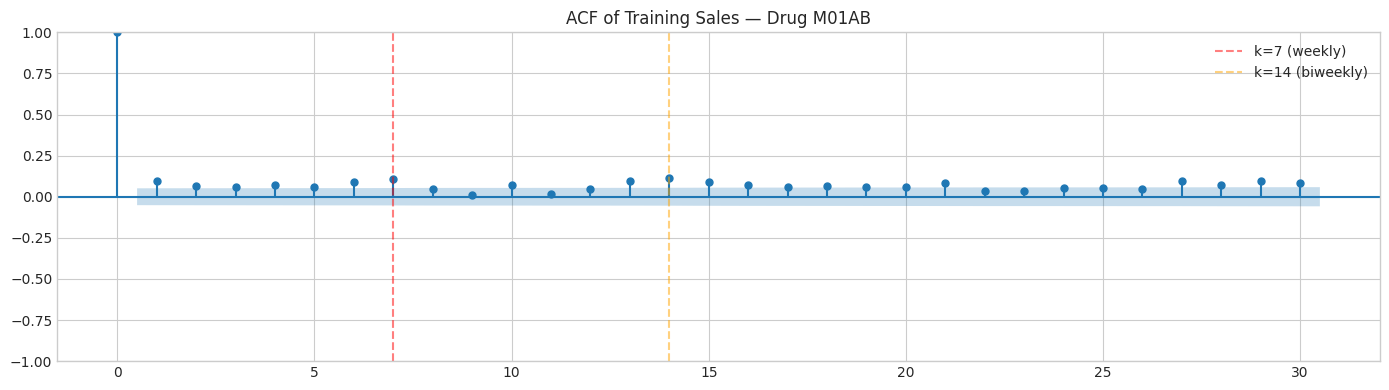

In [2]:
# Step 1: Pre-Training Suitability — ACF Plot
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(train_series.fillna(0), lags=30, ax=ax, title=f'ACF of Training Sales — Drug {TARGET_DRUG}')
ax.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='k=7 (weekly)')
ax.axvline(x=14, color='orange', linestyle='--', alpha=0.5, label='k=14 (biweekly)')
ax.legend()
plt.tight_layout()
plt.savefig('m0_acf_lag_suitability.png', dpi=120, bbox_inches='tight')
plt.show()


In [3]:
# Step 2: LAG PARAMETER GRID SEARCH on 2018 Validation Set
candidate_lags = [1, 2, 7, 14, 21, 28, 30, 60, 90, 365]

val_grid_results = []
for k in candidate_lags:
    naive_val_pred = combined_series.shift(k).loc[val_series.index]
    naive_val_pred = naive_val_pred.fillna(train_series.mean())
    m = evaluate_metrics(val_series.values, naive_val_pred.values)
    val_grid_results.append({'k (Lag)': k, 'Label': f'Naive(t-{k})',
                              'Val RMSLE': m['RMSLE'], 'Val RMSE': m['RMSE'],
                              'Val MAE': m['MAE'], 'Val WAPE (%)': m['WAPE (%)']})

grid_df = pd.DataFrame(val_grid_results).sort_values('Val RMSLE').reset_index(drop=True)
best_k = int(grid_df.iloc[0]['k (Lag)'])
best_val_rmsle = grid_df.iloc[0]['Val RMSLE']
print(f"Best Lag Selected: k* = {best_k} (Val RMSLE = {best_val_rmsle:.4f})")


Best Lag Selected: k* = 365 (Val RMSLE = 0.7047)


In [4]:
# Step 3: Retrain on Train+Val, Forecast 2019 Test Holdout with best k*
test_pred_best = full_series.shift(best_k).loc[test_series.index].fillna(combined_series.mean())
test_met = evaluate_metrics(test_series.values, test_pred_best.values)

print("=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 0: OPTIMISED NAIVE BASELINE ===")
print(f"  Best Lag Parameter  : k* = {best_k} days")
for metric, value in test_met.items():
    print(f"  {metric:15s}: {value:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_Naive': np.ceil(test_pred_best.values).astype(int)}).to_csv('m0_naive_preds.csv', index=False)


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 0: OPTIMISED NAIVE BASELINE ===
  Best Lag Parameter  : k* = 365 days
  RMSLE          : 0.6969
  RMSE           : 3.8770
  MAE            : 2.9393
  MAPE (%)       : 91.0513
  WAPE (%)       : 54.4353
